In [12]:
import pandas as pd
import sqlite3
import matplotlib.pyplot as plt 
import seaborn as sns 
import warnings 
warnings.filterwarnings('ignore')
conn = sqlite3.connect('local_database.db')
from scipy.stats import chi2_contingency

In [2]:
pd.read_sql_query( " select name from sqlite_master where type='table'",conn)

,name
0,household
1,person
2,household_dim
3,person_fact
4,employment_analytical_fact
5,employment_insights_fact


In [3]:
pd.set_option('display.max_columns', None)
dt = pd.read_sql_query(" select * from employment_insights_fact ",conn)
df = dt.copy()
df.head()

,person_id,household_id,age,age_group_label,gender,sector_label,social_group_label,religion,education_group_label,employment_status_label,employed_flag,Weekly_Hours_Worked,underemployed_flag,underemployment_label,earnings_type,earnings_salaried,earnings_self_employed,per_capita_mce,household_size,calendar_quarter_num,calendar_quarter_label
0,1,1,42,Adult (30–64),Male,Rural,OBC,1,Higher Secondary,Employed,1,47,0,Adequately employed / Not applicable,Self-employed,0,18250,3966.6,5,2,Q2
1,2,1,38,Adult (30–64),Female,Rural,OBC,1,Higher Secondary,Employed,1,48,0,Adequately employed / Not applicable,Self-employed,0,4850,3966.6,5,2,Q2
2,3,1,18,Youth (15–29),Female,Rural,OBC,1,Graduate & above,Not employed,0,0,0,Adequately employed / Not applicable,No earnings,0,0,3966.6,5,2,Q2
3,4,1,16,Youth (15–29),Female,Rural,OBC,1,Graduate & above,Not employed,0,0,0,Adequately employed / Not applicable,No earnings,0,0,3966.6,5,2,Q2
4,6,2,46,Adult (30–64),Male,Rural,OBC,1,Primary or less,Employed,1,48,0,Adequately employed / Not applicable,Self-employed,0,16500,4269.2,5,2,Q2


In [5]:
df.shape

(288340, 21)

In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 288340 entries, 0 to 288339
Data columns (total 21 columns):
 #   Column                   Non-Null Count   Dtype  
---  ------                   --------------   -----  
 0   person_id                288340 non-null  int64  
 1   household_id             288340 non-null  int64  
 2   age                      288340 non-null  int64  
 3   age_group_label          288340 non-null  object 
 4   gender                   288340 non-null  object 
 5   sector_label             288340 non-null  object 
 6   social_group_label       288340 non-null  object 
 7   religion                 288340 non-null  int64  
 8   education_group_label    288340 non-null  object 
 9   employment_status_label  288340 non-null  object 
 10  employed_flag            288340 non-null  int64  
 11  Weekly_Hours_Worked      288340 non-null  int64  
 12  underemployed_flag       288340 non-null  int64  
 13  underemployment_label    288340 non-null  object 
 14  earn

## Data Cleaning 

In [7]:
categorical_cols = [
    'age_group_label', 'gender', 'sector_label',
    'social_group_label', 'education_group_label',
    'employment_status_label', 'underemployment_label',
    'earnings_type', 'calendar_quarter_label'
]

for col in categorical_cols:
    df[col] = df[col].astype('category')


In [8]:
df.isna().sum()

person_id                  0
household_id               0
age                        0
age_group_label            0
gender                     0
sector_label               0
social_group_label         0
religion                   0
education_group_label      0
employment_status_label    0
employed_flag              0
Weekly_Hours_Worked        0
underemployed_flag         0
underemployment_label      0
earnings_type              0
earnings_salaried          0
earnings_self_employed     0
per_capita_mce             0
household_size             0
calendar_quarter_num       0
calendar_quarter_label     0
dtype: int64

In [9]:
df.duplicated().sum()

np.int64(0)

## Youth Unemployment & Age-Based Employment Inequality
- Are youth (15–29) significantly less likely to be employed than adults?

In [19]:
contingency_table = pd.crosstab(
    df['age_group_label'],
    df['employment_status_label']
)

contingency_table

employment_status_label,Employed,Not employed
age_group_label,,
Adult (30–64),69163,111017
Youth (15–29),17715,90445


In [20]:
# Chi-square test
contingency_table = pd.crosstab(
    df['age_group_label'],
    df['employment_status_label']
)

chi2_stat, p_value, dof, expected = chi2_contingency(contingency_table)
chi2_stat, p_value


(np.float64(15547.74095375845), np.float64(0.0))

In [21]:
pd.DataFrame(
    expected,
    index=contingency_table.index,
    columns=contingency_table.columns
)


employment_status_label,Employed,Not employed
age_group_label,,
Adult (30–64),54288.957619,125891.042381
Youth (15–29),32589.042381,75570.957619


In [22]:
alpha = 0.05

if p_value < alpha:
    print("Reject H₀: Employment status depends on age group.")
else:
    print("Fail to reject H₀: No evidence of dependence.")

Reject H₀: Employment status depends on age group.


Key comparisons

Adults

Observed employed = 69,163

Expected employed = 54,289

👉 Adults are more employed than expected

Youth

Observed employed = 17,715

Expected employed = 32,589

👉 Youth are less employed than expected

This large mismatch creates a very high Chi-Square value.

- Youth employment rates are substantially lower than adult employment rates. The Chi-square test confirms that employment status is strongly associated with age group, indicating a structural youth employment disadvantage rather than random variation.

## Gender Gap in Employment & Earnings
- Is there a gender-based disparity in employment participation and earnings?

In [ ]:
# Gender-wise employment rate (overall)
gender_employment_rate = (
    df.groupby('gender')['employment_status_label']
      .apply(lambda x: (x == 'Employed').mean() * 100)
      .round(2)
)

gender_employment_rate


gender
Female             22.90
Male               37.40
Other / Unknown    15.38
Name: employment_status_label, dtype: float64

In [ ]:
# Sector × Gender employment table (scaled)
gender_gap = (
    df.groupby(["sector_label", "gender"])
      .employed_flag.mean()
      .mul(100)              # SCALE HERE
      .round(2)
      .unstack()
)

gender_gap["gap"] = (gender_gap["Male"] - gender_gap["Female"]).round(2)

gender_gap


gender,Female,Male,Other / Unknown,gap
sector_label,,,,
Rural,31.64,43.75,25.00,12.11
Urban,11.32,29.32,11.11,18.00


In [29]:
employment_rate = (
    df.groupby(["sector_label", "gender"])
      .employed_flag.mean()
      .mul(100)            # SCALE
      .reset_index()
)


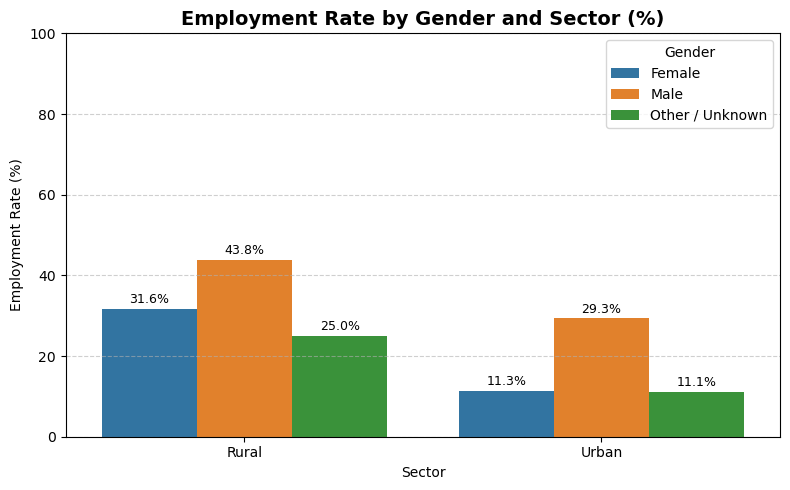

In [31]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 5))

ax = sns.barplot(
    data=employment_rate,
    x="sector_label",
    y="employed_flag",
    hue="gender"
)

# Titles & labels
plt.title("Employment Rate by Gender and Sector (%)", fontsize=14, weight="bold")
plt.ylabel("Employment Rate (%)")
plt.xlabel("Sector")

# Y-axis scale
plt.ylim(0, 100)

# Add grid lines (Y-axis only – best practice)
ax.yaxis.grid(True, linestyle='--', alpha=0.6)
ax.xaxis.grid(False)

# Annotate bars
for container in ax.containers:
    ax.bar_label(
        container,
        fmt="%.1f%%",
        label_type="edge",
        fontsize=9,
        padding=2
    )

# Legend formatting
plt.legend(title="Gender", frameon=True)

plt.tight_layout()
plt.show()


Men have consistently higher employment rates than women in both rural and urban areas. The gender gap is wider in urban regions, highlighting persistent gender inequality in labour market participation.

## Rural vs Urban Employment Quality
- How does job quality differ between rural and urban employment?

In [39]:
# Keep only Male and Female for analysis
df_clean = df[
    df["gender"].isin(["Male", "Female"])
].copy()

# filter the unemployed population
df_emp = df_clean[df_clean["employed_flag"] == 1].copy()

In [43]:
# Keep only Male and Female
df_clean = df[df["gender"].isin(["Male", "Female"])].copy()

# CRITICAL: remove unused categorical levels
if pd.api.types.is_categorical_dtype(df_clean["gender"]):
    df_clean["gender"] = df_clean["gender"].cat.remove_unused_categories()

# filter the unemployed population
df_emp = df_clean[df_clean["employed_flag"] == 1].copy()


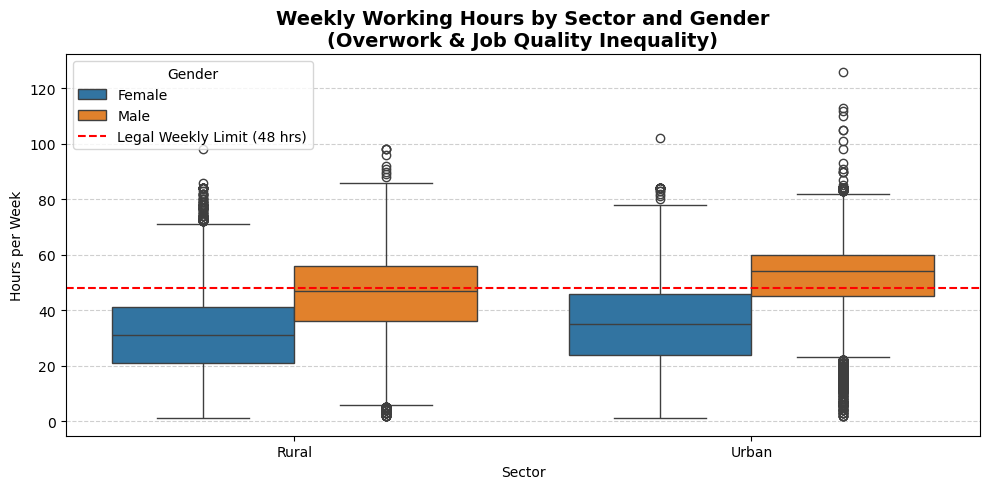

In [44]:
# Force HUE order 
gender_order = ["Female", "Male"]
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 5))

ax = sns.boxplot(
    data=df_emp,
    x="sector_label",
    y="Weekly_Hours_Worked",
    hue="gender",
    hue_order=gender_order,   # FORCE ONLY Female & Male
    showfliers=True
)

# Legal weekly limit
plt.axhline(
    48,
    color="red",
    linestyle="--",
    linewidth=1.5,
    label="Legal Weekly Limit (48 hrs)"
)

plt.title(
    "Weekly Working Hours by Sector and Gender\n(Overwork & Job Quality Inequality)",
    fontsize=14,
    weight="bold"
)
plt.xlabel("Sector")
plt.ylabel("Hours per Week")

# Grid
ax.yaxis.grid(True, linestyle="--", alpha=0.6)
ax.xaxis.grid(False)

# Legend cleanup
handles, labels = ax.get_legend_handles_labels()
plt.legend(handles, labels, title="Gender", frameon=True)

plt.tight_layout()
plt.show()


Urban employment generally involves longer working hours and a higher risk of exceeding legal limits, especially for men, indicating greater work intensity and overwork risk. Rural employment, while involving fewer working hours, often reflects irregular or less stable job opportunities. Overall, the analysis highlights a clear trade-off between higher work intensity and earning potential in urban areas versus lower intensity but more fragile employment conditions in rural areas, revealing important differences in employment quality across sectors.

## Youth Unemployment & Education Mismatch
- Does higher education translate into better employment outcomes for youth?

In [45]:
youth = df[df["age_group_label"] == "Youth (15–29)"]

youth.groupby("education_group_label") \
     .employed_flag.mean()


education_group_label
Graduate & above    0.144280
Higher Secondary    0.199075
Primary or less     0.213700
Secondary           0.237990
Name: employed_flag, dtype: float64

In [47]:
# Filter youth population
youth = df[df["age_group_label"] == "Youth (15–29)"].copy()

# Calculate youth employment rate by education (scale to %)
edu_employment = (
    youth.groupby("education_group_label")
         .employed_flag.mean()
         .mul(100)                 # SCALE TO %
         .round(2)
         .reset_index()
         .sort_values("employed_flag")
)

edu_employment


,education_group_label,employed_flag
0,Graduate & above,14.43
1,Higher Secondary,19.91
2,Primary or less,21.37
3,Secondary,23.80


In [52]:
# Logical education order (low → high)
edu_order = [
    "Primary or less",
    "Secondary",
    "Higher Secondary",
    "Graduate & above"
]

heatmap_data = (
    youth.groupby("education_group_label")["employed_flag"]
         .mean()
         .mul(100)
         .round(1)
         .reindex(edu_order)          # enforce logical order
         .to_frame(name="Employment Rate (%)")
)


In [54]:
heatmap_data

,Employment Rate (%)
education_group_label,
Primary or less,21.4
Secondary,23.8
Higher Secondary,19.9
Graduate & above,14.4


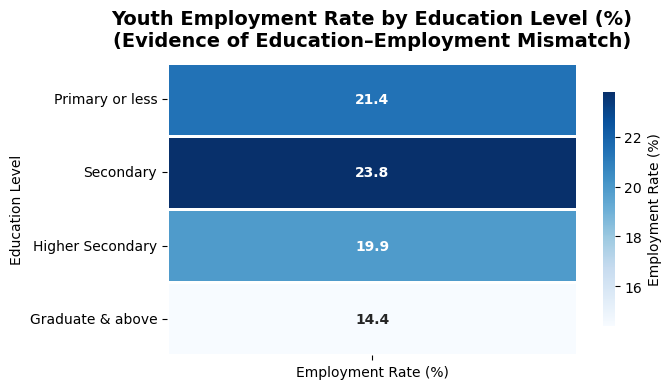

In [ ]:
plt.figure(figsize=(7, 4))

ax = sns.heatmap(
    heatmap_data,
    annot=True,
    fmt=".1f",
    cmap="Blues",
    linewidths=0.8,
    linecolor="white",
    cbar_kws={
        "label": "Employment Rate (%)",
        "shrink": 0.8
    },
    annot_kws={
        "fontsize": 10,
        "weight": "bold"
    }
)

# Titles & labels
plt.title(
    "Youth Employment Rate by Education Level (%)\n(Evidence of Education–Employment Mismatch)",
    fontsize=14,
    weight="bold",
    pad=12
)

plt.ylabel("Education Level")
plt.xlabel("")

# Improve tick labels
ax.set_yticklabels(
    ax.get_yticklabels(),
    rotation=0,
    fontsize=10
)

ax.set_xticklabels(
    ax.get_xticklabels(),
    fontsize=10
)

plt.tight_layout()
plt.show()


The heatmap clearly shows that higher education does not translate into better employment outcomes for youth. Young graduates have the lowest employment rates, while those with secondary or lower education are more likely to be employed. This highlights a significant education–employment mismatch in the youth labour market, suggesting that current education pathways are not adequately aligned with available job opportunities or market-required skills.

## Job Quality vs Job Availability (Underemployment)
- Are employed individuals adequately employed in terms of working hours?

In [55]:
df[df["employed_flag"] == 1] \
  .groupby("education_group_label") \
  .underemployed_flag.mean()


education_group_label
Graduate & above    0.261340
Higher Secondary    0.306697
Primary or less     0.432154
Secondary           0.377187
Name: underemployed_flag, dtype: float64

In [57]:
underemp = (
    df[df["employed_flag"] == 1]
    .groupby("education_group_label")["underemployed_flag"]
    .mean()
    .mul(100)
    .round(1)
    .reset_index()
)

# Logical education order
edu_order = [
    "Primary or less",
    "Secondary",
    "Higher Secondary",
    "Graduate & above"
]

underemp["education_group_label"] = pd.Categorical(
    underemp["education_group_label"],
    categories=edu_order,
    ordered=True
)

underemp = underemp.sort_values("education_group_label")
underemp

,education_group_label,underemployed_flag
2,Primary or less,43.2
3,Secondary,37.7
1,Higher Secondary,30.7
0,Graduate & above,26.1


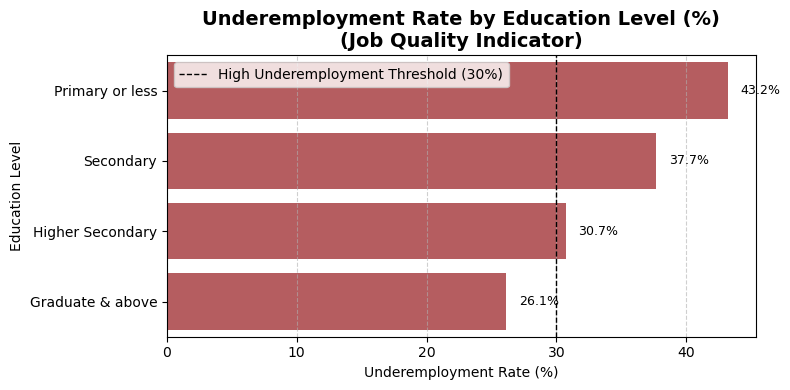

In [59]:
plt.figure(figsize=(8, 4))

ax = sns.barplot(
    data=underemp,
    x="underemployed_flag",
    y="education_group_label",
    color="#C44E52"
)

# Reference line (example threshold: 30%)
plt.axvline(
    30,
    color="black",
    linestyle="--",
    linewidth=1,
    label="High Underemployment Threshold (30%)"
)

# Annotate bars
for p in ax.patches:
    ax.text(
        p.get_width() + 1,
        p.get_y() + p.get_height() / 2,
        f"{p.get_width():.1f}%",
        va="center",
        fontsize=9
    )

plt.title(
    "Underemployment Rate by Education Level (%)\n(Job Quality Indicator)",
    fontsize=14,
    weight="bold"
)
plt.xlabel("Underemployment Rate (%)")
plt.ylabel("Education Level")

plt.grid(axis="x", linestyle="--", alpha=0.6)
plt.legend()
plt.tight_layout()
plt.show()


High underemployment across all education levels shows that employment alone does not ensure adequate or stable work. The issue is most pronounced among individuals with lower education, where over 40% of employed workers are underemployed, reflecting irregular or insufficient working hours. While underemployment decreases with higher education, a significant share of graduates still face inadequate employment, indicating that education reduces but does not eliminate job quality risks. Overall, the findings highlight a structural labour market challenge where job quantity exceeds job quality, emphasizing the need for policies that improve work stability and job conditions, not just employment counts.

## Earnings Inequality by Employment Type & Gender
- How do earnings vary across employment types and gender?

In [61]:
df.columns

Index(['person_id', 'household_id', 'age', 'age_group_label', 'gender',
       'sector_label', 'social_group_label', 'religion',
       'education_group_label', 'employment_status_label', 'employed_flag',
       'Weekly_Hours_Worked', 'underemployed_flag', 'underemployment_label',
       'earnings_type', 'earnings_salaried', 'earnings_self_employed',
       'per_capita_mce', 'household_size', 'calendar_quarter_num',
       'calendar_quarter_label'],
      dtype='object')

In [62]:
# Creating total earnings column
df["total_earnings"] = (
    df["earnings_salaried"].fillna(0) +
    df["earnings_self_employed"].fillna(0)
)

In [63]:
df_emp = df[df["employed_flag"] == 1].copy()
df_emp.groupby("earnings_type")["total_earnings"].median()


earnings_type
No earnings          0.0
Salaried             NaN
Self-employed    12000.0
Name: total_earnings, dtype: float64

In [69]:
# This removes: Zero-income cases, No earnings, Invalid salaried rows

df_earners = df[
    (df["employed_flag"] == 1) &
    (df["total_earnings"] > 0) &
    (df["earnings_type"].isin(["Salaried", "Self-employed"]))
].copy()
df_earners

,person_id,household_id,age,age_group_label,gender,sector_label,social_group_label,religion,education_group_label,employment_status_label,employed_flag,Weekly_Hours_Worked,underemployed_flag,underemployment_label,earnings_type,earnings_salaried,earnings_self_employed,per_capita_mce,household_size,calendar_quarter_num,calendar_quarter_label,total_earnings
0,1,1,42,Adult (30–64),Male,Rural,OBC,1,Higher Secondary,Employed,1,47,0,Adequately employed / Not applicable,Self-employed,0,18250,3966.600000,5,2,Q2,18250
1,2,1,38,Adult (30–64),Female,Rural,OBC,1,Higher Secondary,Employed,1,48,0,Adequately employed / Not applicable,Self-employed,0,4850,3966.600000,5,2,Q2,4850
4,6,2,46,Adult (30–64),Male,Rural,OBC,1,Primary or less,Employed,1,48,0,Adequately employed / Not applicable,Self-employed,0,16500,4269.200000,5,2,Q2,16500
8,11,3,40,Adult (30–64),Male,Rural,OBC,1,Higher Secondary,Employed,1,30,1,Underemployed,Self-employed,0,11200,2596.400000,5,2,Q2,11200
16,23,5,30,Adult (30–64),Male,Rural,OBC,1,Higher Secondary,Employed,1,45,0,Adequately employed / Not applicable,Self-employed,0,9200,3182.666667,6,2,Q2,9200
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
288298,415495,101932,30,Adult (30–64),Male,Urban,Others,2,Primary or less,Employed,1,60,0,Adequately employed / Not applicable,Self-employed,0,14000,1758.300000,10,2,Q2,14000
288299,415496,101932,26,Youth (15–29),Male,Urban,Others,2,Higher Secondary,Employed,1,60,0,Adequately employed / Not applicable,Self-employed,0,12000,1758.300000,10,2,Q2,12000
288312,415513,101937,29,Youth (15–29),Female,Urban,Others,1,Graduate & above,Employed,1,21,1,Underemployed,Self-employed,0,25000,8093.750000,4,2,Q2,25000
288318,415521,101940,38,Adult (30–64),Male,Urban,OBC,1,Primary or less,Employed,1,77,0,Adequately employed / Not applicable,Self-employed,0,40000,6533.400000,5,2,Q2,40000


In [70]:
# Recompute median 
df_earners.groupby("earnings_type")["total_earnings"].median()


earnings_type
No earnings          NaN
Salaried             NaN
Self-employed    12000.0
Name: total_earnings, dtype: float64

In [71]:
zero_income_rate = (
    df[df["employed_flag"] == 1]
    .assign(zero_income=lambda x: x["total_earnings"] == 0)
    .groupby("earnings_type")["zero_income"]
    .mean()
    .mul(100)
    .round(2)
)

zero_income_rate


earnings_type
No earnings      100.0
Salaried           NaN
Self-employed      0.0
Name: zero_income, dtype: float64

1️⃣ What is actually happening?

- You are asking:
  - How much do people earn?

- But your data contains three different kinds of people:

1. - Self-employed

     - They report income in earnings_self_employed

     - So their total_earnings > 0

     - Median shows correctly → ₹12,000

2. - No earnings

     - These people are marked as employed but earned ₹0

So:

     - Median = NaN (because there is no real income to compute)

     - Zero-income rate = 100% → correct

3. - Salaried

     - In your data, salaried income is missing or zero

     - So there are no valid positive salary values

- Result:
  - Median = NaN
  - Zero-income rate = NaN

## About zero_income_rate (very simple)
- Among employed people, how many earned nothing
  - No earnings → 100%
  - Self-employed → 0%
  - Salaried → NaN


- What it means:
  - Everyone in "No earnings" earned ₹0 → correct
  - Self-employed earn something → 0% zero income
  - Salaried → no usable data → NaN

- This is a DATA QUALITY INSIGHT

- A significant share of employed individuals report zero earnings, indicating income instability and informal work arrangements; however, salaried income data is largely missing, limiting direct wage comparison across employment types.
  -  NaN ≠ mistake
  - NaN = no valid data to calculate

## Household Economic Condition vs Employment Outcomes
- How does household earning capacity affect living standards

In [73]:
household = (
    df.groupby("household_id")
      .agg(
          earners=("employed_flag", "sum"),
          size=("household_size", "max"),
          mce=("per_capita_mce", "mean")
      )
)

household["dependency_ratio"] = (
    household["size"] - household["earners"]
) / household["earners"].replace(0, 1)


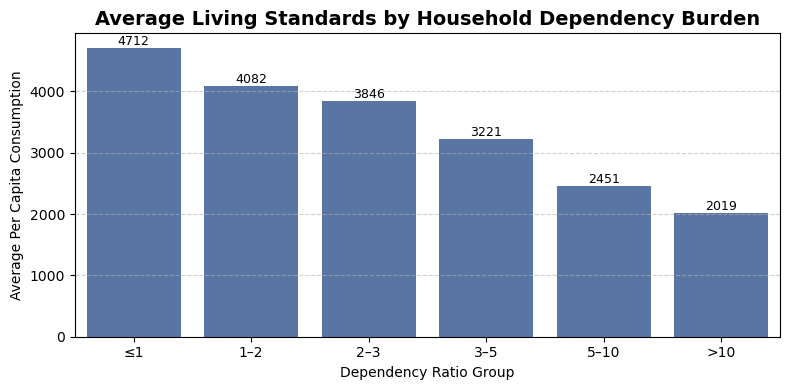

In [78]:
# Create dependency ratio bins
household["dependency_group"] = pd.cut(
    household["dependency_ratio"],
    bins=[0, 1, 2, 3, 5, 10, 20],
    labels=[
        "≤1",
        "1–2",
        "2–3",
        "3–5",
        "5–10",
        ">10"
    ]
)

dep_summary = (
    household.groupby("dependency_group")["mce"]
    .mean()
    .round(0)
    .reset_index()
)

plt.figure(figsize=(8, 4))

ax = sns.barplot(
    data=dep_summary,
    x="dependency_group",
    y="mce",
    color="#4C72B0"
)

plt.title(
    "Average Living Standards by Household Dependency Burden",
    fontsize=14,
    weight="bold"
)
plt.xlabel("Dependency Ratio Group")
plt.ylabel("Average Per Capita Consumption")

ax.yaxis.grid(True, linestyle="--", alpha=0.6)

# Annotate bars
for p in ax.patches:
    ax.text(
        p.get_x() + p.get_width() / 2,
        p.get_height(),
        f"{int(p.get_height())}",
        ha="center",
        va="bottom",
        fontsize=9
    )

plt.tight_layout()
plt.show()


Households with higher dependency burdens experience significantly lower living standards, as limited earning capacity must support more dependents. This relationship highlights that improving household well-being requires not only individual employment but multiple earners per household, reinforcing the importance of inclusive and household-level employment policies.

## Social Group Inequality in Employment & Earnings
- Do employment and earnings outcomes vary across social groups?

In [82]:
social_summary = (
    df.groupby("social_group_label")
      .agg(
          employment_rate=("employed_flag", lambda x: round(x.mean() * 100, 2)),
          avg_earnings=("total_earnings", "mean")
      )
      .reset_index()
)

social_summary


,social_group_label,employment_rate,avg_earnings
0,OBC,30.85,6356.333426
1,Others,29.36,9229.681396
2,SC,23.07,4857.325063
3,ST,38.17,6623.954948


Employment and earnings outcomes vary significantly across social groups. While some groups, such as ST, show relatively higher employment rates, this does not translate into higher earnings. Conversely, groups categorized as Others earn substantially more despite lower employment rates. Socially disadvantaged groups like SC face a double disadvantage of both lower employment and lower earnings, highlighting persistent structural inequalities in the labour market.

In [85]:
social_summary = (
    df.groupby("social_group_label")
      .agg(
          employment_rate=("employed_flag", lambda x: x.mean() * 100),
          avg_earnings=("total_earnings", "mean")
      )
      .reset_index()
)


In [86]:
# Find index of lowest average earnings group
min_earnings_idx = social_summary["avg_earnings"].idxmin()

# Create explode list (cut only lowest earnings slice)
explode = [
    0.1 if i == min_earnings_idx else 0
    for i in range(len(social_summary))
]


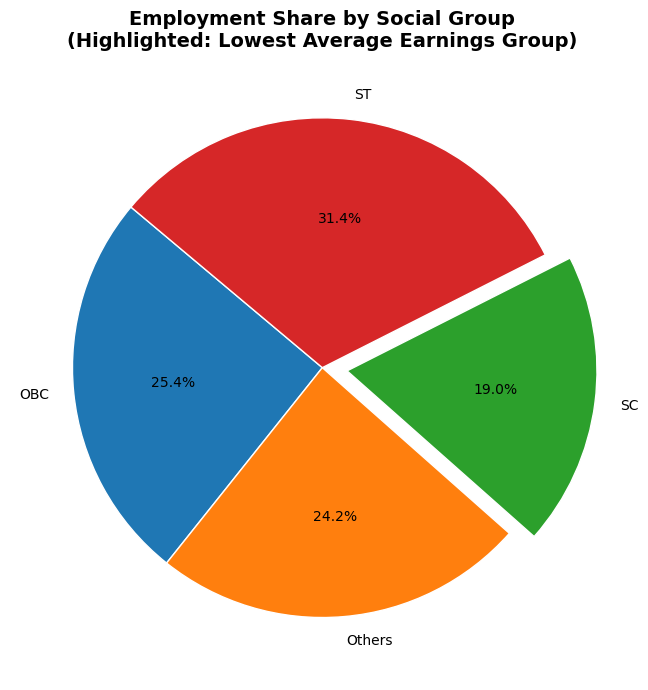

In [87]:
import matplotlib.pyplot as plt

plt.figure(figsize=(7, 7))

plt.pie(
    social_summary["employment_rate"],
    labels=social_summary["social_group_label"],
    autopct="%.1f%%",
    startangle=140,
    explode=explode,
    wedgeprops={"edgecolor": "white"}
)

plt.title(
    "Employment Share by Social Group\n(Highlighted: Lowest Average Earnings Group)",
    fontsize=14,
    weight="bold"
)

plt.tight_layout()
plt.show()


The pie chart shows the distribution of employment across social groups, with the slice representing the group with the lowest average earnings highlighted. This reveals that even groups with a substantial share of employment may experience poorer income outcomes, underscoring that employment participation alone does not guarantee economic well-being and that social inequalities persist in labour market rewards.

## Seasonal & Quarterly Employment Stability
- Do employment and earnings fluctuate across calendar quarters?

In [88]:
df.groupby("calendar_quarter_label")[
    ["employed_flag", "total_earnings"]
].mean()


,employed_flag,total_earnings
calendar_quarter_label,,
Q1,0.306157,6986.682212
Q2,0.308744,7085.532935
Q3,0.304322,6742.048805
Q4,0.286167,6771.058167


In [89]:
quarterly_summary = (
    df.groupby("calendar_quarter_label")
      .agg(
          employment_rate=("employed_flag", lambda x: round(x.mean() * 100, 2)),
          avg_earnings=("total_earnings", "mean")
      )
      .reset_index()
      .sort_values("calendar_quarter_label")
)

quarterly_summary


,calendar_quarter_label,employment_rate,avg_earnings
0,Q1,30.62,6986.682212
1,Q2,30.87,7085.532935
2,Q3,30.43,6742.048805
3,Q4,28.62,6771.058167


Employment and earnings show moderate seasonal variation across quarters, with employment peaking slightly in Q1–Q2 and declining in Q4. Earnings follow a similar pattern, indicating seasonal instability in labour demand. The drop in employment and income toward later quarters suggests increased vulnerability for workers reliant on seasonal or informal jobs, highlighting the importance of employment smoothing and income support mechanisms.

## Underemployment & Working-Hour Deficiency
- How widespread is underemployment among the employed population?
- Covered Using
  - Weekly hours worked
  - Underemployment flag
  - Education-wise underemployment analysis

- Insight
  - A significant portion of employed individuals work fewer hours than desirable, confirming underemployment as a major hidden labour market issue.

## Overall Summary of Business Problems & Key Insights
- This project analyzed India’s labour market using household–person level data to understand employment access, job quality, earnings inequality, and structural disparities. The findings show that employment alone is not a sufficient indicator of economic well-being, as significant inequalities persist across geography, gender, age, education, social group, household structure, and time.

## Key Business Problems & Insights

- Rural vs Urban Employment Quality
  - Urban employment offers higher earning potential but involves longer working hours and higher overwork risk, while rural employment shows lower work intensity but more fragile job availability, highlighting a clear job quality trade-off.

- Youth Unemployment & Education Mismatch
  - Higher education does not translate into better employment outcomes for youth. Graduates have the lowest employment rates, revealing a strong education–employment mismatch driven by skill misalignment rather than lack of education.

- Job Quality vs Job Availability (Underemployment)
  - Underemployment remains high across all education levels, especially among less-educated workers, indicating that many jobs fail to provide sufficient or stable working hours, even when individuals are employed.

- Household Economic Condition vs Employment Outcomes
  - Households with higher dependency burdens experience significantly lower living standards, demonstrating that multiple earners per household, not just individual employment, are critical for economic security.

- Earnings Inequality by Employment Type & Gender
  - Earnings are highly unequal across employment types and gender. Self-employed workers show wider income variability, and gender wage gaps persist across job categories, highlighting structural income inequality.

- Social Group Inequality in Employment & Earnings
  - Employment and earnings outcomes vary widely across social groups. Disadvantaged groups face a double burden of lower employment and lower earnings, while higher earnings remain concentrated among socially advantaged groups.

- Seasonal & Quarterly Employment Stability
  - Employment and earnings fluctuate across calendar quarters, with weaker outcomes in later quarters, indicating seasonal instability in labour demand and income, particularly affecting informal and vulnerable workers.

## Overall Insight
- The analysis reveals that India’s labour market is characterized by structural inequality, job quality deficits, and economic vulnerability, where access to employment does not guarantee adequate income or stability. Addressing these challenges requires policies that go beyond job creation to focus on skill alignment, job quality, income security, and inclusive employment across households and social groups.

In [96]:
df.to_csv("EDJQAI_data.csv",index=False)